In [7]:
import matplotlib.pyplot as plt 
from sklearn.model_selection import  train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [12]:
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns


In [31]:
#train a model using pipeline
#load the irirs datasets
data = load_iris()
X,y = data.data,data.target
labels= data.feature_names

In [32]:
#Instiate a pipeline consisting of StandardScaler,PCA,KNeighborsClassifiers
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components= 2,)),
    ('knn',KNeighborsClassifier(n_neighbors = 5,))
])

In [33]:
#split the data into training date set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42,stratify = y)

In [34]:
#fit the pipeline on the trainig set
pipeline.fit(X_train,y_train)

#measure the pipeline accuracy on the test data 
test_score = pipeline.score(X_test,y_test)
print(f"{test_score:.3f}")

0.900


In [35]:
#get the model prediction
y_pred = pipeline.predict(X_test)

In [36]:
#generate the confusion_matrix and plot it
confusion_matrix = confusion_matrix(y_test,y_pred)

TypeError: 'numpy.ndarray' object is not callable

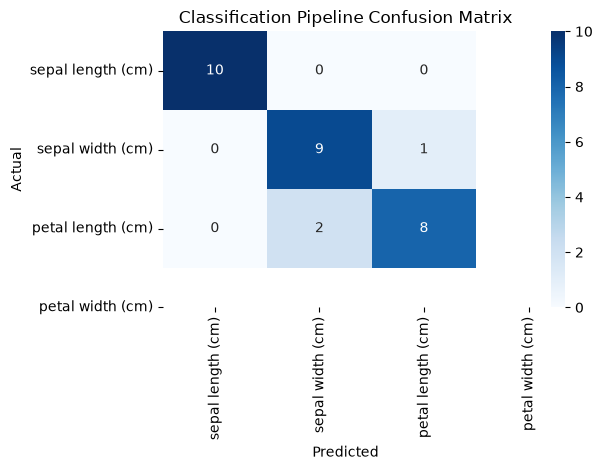

In [37]:
#create a single plot for confusion matrix
plt.figure()
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [39]:
#tune hyperparameter using pipeline within cross validation gridsearch
pipeline = Pipeline(
    [
        ('scaler',StandardScaler),
        ('pca',PCA()),
        ('knn',KNeighborsClassifier)
    ]
)

In [40]:
#hyperparameter serach grid to for number of PCA COMPONENTS AND Kneighbors
param_grid = {
    'pca_n_components':[2,3],
    'knn_n_neighbors':[3,5,7]
}

In [41]:
#choose a cross validation
#to ensure target is startified we ude standardscaler cross validation
cv = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 42)

In [44]:
best_model = GridSearchCV(
    estimator = pipeline,
    param_grid =param_grid ,
    cv = cv,
    scoring = 'accuracy',
    verbose =2
)